Original AskPrice Skewness: 8.39
Log-Transformed AskPrice Skewness: 0.42


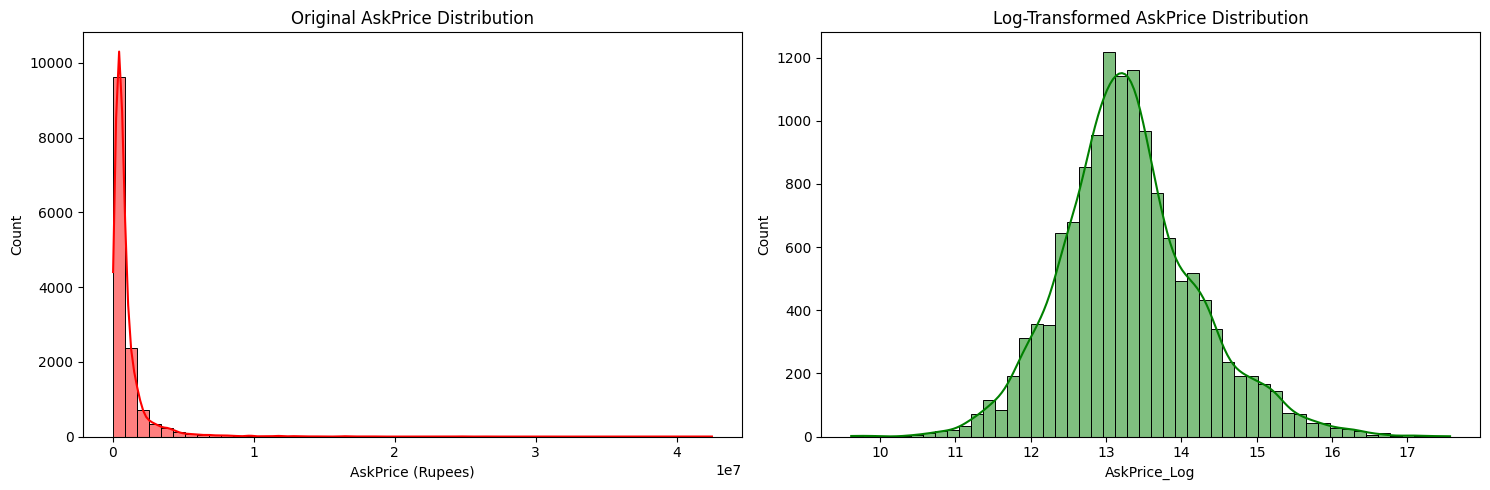

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data (assuming your notebook is in the 'notebooks' folder)
df = pd.read_csv('../data/interim/used_cars_cleaned.csv')

# 2. Apply the Log1p transform
df['AskPrice_Log'] = np.log1p(df['AskPrice'])

# 3. Calculate numerical skewness
original_skew = df['AskPrice'].skew()
log_skew = df['AskPrice_Log'].skew()

print(f"Original AskPrice Skewness: {original_skew:.2f}")
print(f"Log-Transformed AskPrice Skewness: {log_skew:.2f}")

# 4. Visual Verification
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Original
sns.histplot(df['AskPrice'], kde=True, ax=axes[0], color='red', bins=50)
axes[0].set_title('Original AskPrice Distribution')
axes[0].set_xlabel('AskPrice (Rupees)')

# Plot Log Transformed
sns.histplot(df['AskPrice_Log'], kde=True, ax=axes[1], color='green', bins=50)
axes[1].set_title('Log-Transformed AskPrice Distribution')
axes[1].set_xlabel('AskPrice_Log')

plt.tight_layout()
plt.show()

In [5]:
# 1. Clean FuelType casing
df['FuelType'] = df['FuelType'].str.lower()

# 2. Drop the redundant Year column
if 'Year' in df.columns:
    df = df.drop(columns=['Year'])

# 3. Cap kmDriven at 300,000
df['kmDriven'] = df['kmDriven'].clip(upper=300000)

# Verification
print("Unique Fuel Types:", df['FuelType'].unique().tolist())
print("Max kmDriven after clipping:", df['kmDriven'].max())
print("Columns remaining:", df.columns.tolist())

Unique Fuel Types: ['petrol', 'diesel', 'hybrid/cng', 'hybrid']
Max kmDriven after clipping: 300000.0
Columns remaining: ['Brand', 'model', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice', 'AskPrice_Log']
